In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention, LayerNormalization, Dropout, GlobalAveragePooling1D
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

I0000 00:00:1788805939.155283 1432132 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788805939.195406 1432132 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788805940.342349 1432132 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
df = pd.read_excel('NGC-13Vs.xlsx', sheet_name='All Vs')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [4]:
df.head()

,Petroleum,Bioenergy&Waste,Nuclear,Renewables (wind,GDP,Pop,Temp,Rainfall,WinsSpeed,DailySunHours,EnergyInt,RP-Gas,RP-Elec,Natural Gas
Month,,,,,,,,,,,,,,
1995-01-01,6.16,0.14,1.51,0.0,5610,57.955000,4.9,NaN,NaN,NaN,5.0,58.9,86.5,8.90
1995-02-01,6.32,0.14,1.59,0.0,5610,57.966633,6.7,NaN,NaN,NaN,5.0,59.1,86.3,7.16
1995-03-01,6.96,0.14,1.91,0.0,5610,57.978267,5.6,NaN,NaN,NaN,5.0,59.5,86.3,7.91
1995-04-01,6.08,0.14,1.78,0.0,5613,57.989900,8.9,NaN,NaN,NaN,5.0,59.2,85.6,5.75
1995-05-01,6.23,0.14,1.55,0.0,5613,58.001533,11.6,NaN,NaN,NaN,5.0,59.2,85.4,4.79


In [5]:
df['Month_Num'] = df.index.month

missing_cols = ['Rainfall', 'WinsSpeed', 'DailySunHours']
monthly_means = df.groupby('Month_Num')[missing_cols].mean()

for col in missing_cols:
    df[col] = df.apply(
        lambda row: monthly_means.loc[row['Month_Num'], col] if pd.isna(row[col]) else row[col],
        axis=1
    )

df['Month_Sin'] = np.sin(2 * np.pi * df['Month_Num'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month_Num'] / 12)
df.drop('Month_Num', axis=1, inplace=True)

target_col = 'Natural Gas'
target_idx = df.columns.get_loc(target_col)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns, index=df.index)

def create_sequences(data, target_col, seq_length=12):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    data_array = data.values
    
    for i in range(len(data_array) - seq_length):
        X.append(data_array[i:(i + seq_length)])
        y.append(data_array[i + seq_length, target_idx])
        
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df, target_col='Natural Gas', seq_length=12)

print(f"Total NaNs after processing: {scaled_df.isna().sum().sum()}")
print(f"X shape: {X.shape} (Samples, Sequence Length, Features)")
print(f"y shape: {y.shape}")

Total NaNs after processing: 0
X shape: (343, 12, 16) (Samples, Sequence Length, Features)
y shape: (343,)


I0000 00:00:1788805942.984042 1432132 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4130 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1788805945.771189 1432571 cuda_dnn.cc:461] Loaded cuDNN version 92200


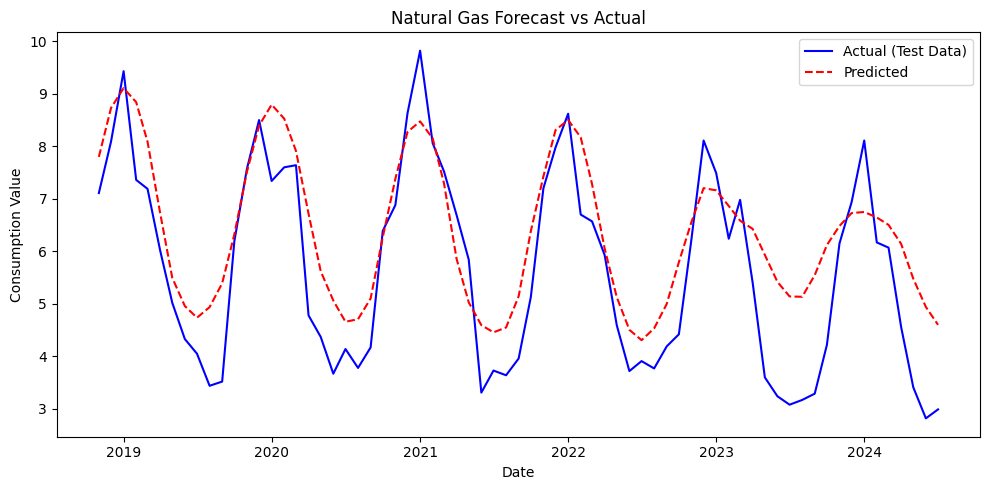

In [6]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

seq_length = X.shape[1]
num_features = X.shape[2]
inputs = Input(shape=(seq_length, num_features))
lstm_out = LSTM(64, return_sequences=True)(inputs)
attention_out = MultiHeadAttention(num_heads=4, key_dim=64)(lstm_out, lstm_out)
attention_out = LayerNormalization()(lstm_out + attention_out)
attention_out = Dropout(0.2)(attention_out)
pooled = GlobalAveragePooling1D()(attention_out)
dense_out = Dense(32, activation='relu')(pooled)
outputs = Dense(1, activation='linear')(dense_out)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test), verbose=0)

y_pred_scaled = model.predict(X_test, verbose=0)

y_test_full = np.zeros((len(y_test), scaled_df.shape[1]))
y_pred_full = np.zeros((len(y_pred_scaled), scaled_df.shape[1]))

y_test_full[:, target_idx] = y_test.flatten()
y_pred_full[:, target_idx] = y_pred_scaled.flatten()

y_test_rescaled = scaler.inverse_transform(y_test_full)[:, target_idx]
y_pred_rescaled = scaler.inverse_transform(y_pred_full)[:, target_idx]

test_dates = scaled_df.index[split_idx + seq_length:]

plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_rescaled, label='Actual (Test Data)', color='blue')
plt.plot(test_dates, y_pred_rescaled, label='Predicted', color='red', linestyle='--')
plt.title('Natural Gas Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Consumption Value')
plt.legend()
plt.tight_layout()

In [7]:
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100
r2 = r2_score(y_test_rescaled, y_pred_rescaled)


print(f"MAE : {round(mae, 3)}")
print(f"RMSE: {round(rmse, 3)}")
print(f"MAPE (%): {round(mape, 2)}")
print(f"R-squared: {round(r2, 3)}")

MAE : 0.922
RMSE: 1.118
MAPE (%): 21.1
R-squared: 0.64
